<a href="https://colab.research.google.com/github/aleeseyon/GEOP592/blob/main/GEOP609_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blackfoot/Cavalier reservoir-interval clustering

Unsupervised clustering of well-log facies in the user-defined TOP-BASE intervals
of five wells (A-E), using three petrophysically informative features:

- **Vp** (m/s), computed from DT (us/m) as 1e6/DT
- **DPSS** (fractional density-porosity, sandstone matrix)
- **GR** (gamma ray, API)

**References used in this analysis:**
- Mavko, G., Mukerji, T., & Dvorkin, J. (2009). *The Rock Physics Handbook* (2nd ed.). Cambridge UP.
- Castagna, J.P., Batzle, M.L., & Eastwood, R.L. (1985). Relationships between compressional-wave and shear-wave velocities in clastic silicate rocks. *Geophysics*, 50(4), 571-581.
- Margrave, G.F., Lawton, D.C., & Stewart, R.R. (1998). Interpreting channel sands with 3C-3D seismic data. *The Leading Edge*, 17(4), 509-513.
- Rousseeuw, P.J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *J. Comp. Appl. Math.*, 20, 53-65.
- Schwarz, G. (1978). Estimating the dimension of a model. *Annals of Statistics*, 6(2), 461-464.


## 0. Upload the CSV

Run the cell below, then upload `blackfoot_reservoir_intervals.csv`.

In [30]:
# In Colab: uncomment the next two lines to upload the CSV.
# from google.colab import files
# files.upload()

# If running locally, set CSV_PATH to your file path.
CSV_PATH = "blackfoot_reservoir_intervals.csv"


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110


In [44]:
# Install kaleido for saving plotly figures
!pip install kaleido

import os

# Create a directory to save plots
if not os.path.exists('plots'):
    os.makedirs('plots')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.2 MB/s eta 0:00:00


## 1. Load and QC

In [33]:
df = pd.read_csv('/content/GEOP609_reservoir_intervals.csv')
print(df.shape)
print(df.head())
print()
print(df.groupby("WELL").size())
print()
print(df.describe().round(2))

(3816, 5)
  WELL   DEPTH_M      VP_MS   DPSS  GR_API
0    A  1621.875  4430.2087  0.060  74.155
1    A  1622.000  4457.7782  0.060  72.243
2    A  1622.125  4478.5210  0.051  78.974
3    A  1622.250  4556.9920  0.036  87.321
4    A  1622.375  4515.0804  0.030  95.734

WELL
A    784
B    795
C    792
D    649
E    796
dtype: int64

       DEPTH_M    VP_MS     DPSS   GR_API
count  3816.00  3816.00  3816.00  3816.00
mean   1659.61  4099.93     0.09    79.96
std      71.93   489.55     0.11    26.67
min    1489.25  2484.48    -0.25    15.72
25%    1628.68  3826.59     0.03    63.10
50%    1677.62  4117.31     0.06    84.37
75%    1709.40  4340.95     0.12    99.70
max    1779.25  7434.06     0.79   246.87


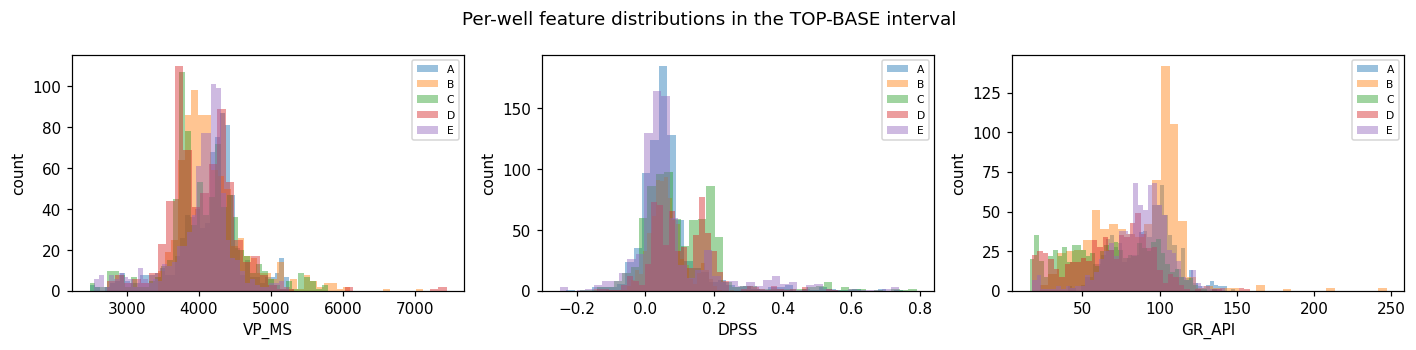

In [34]:
# Histograms by feature, coloured by well
features = ["VP_MS", "DPSS", "GR_API"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, f in zip(axes, features):
    for w, sub in df.groupby("WELL"):
        ax.hist(sub[f].dropna(), bins=40, alpha=0.45, label=w)
    ax.set_xlabel(f); ax.set_ylabel("count"); ax.legend(fontsize=7)
plt.suptitle("Per-well feature distributions in the TOP-BASE interval")
plt.tight_layout(); plt.show()


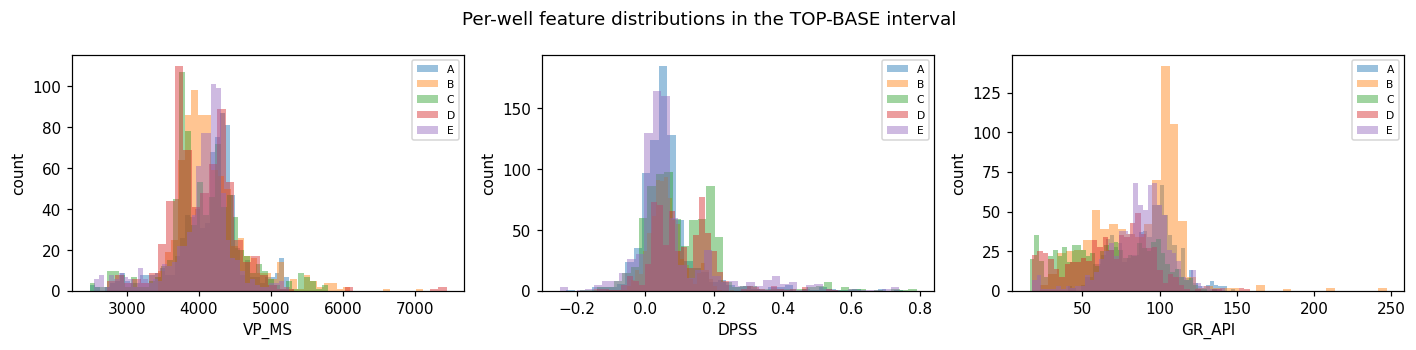

In [35]:
# Histograms by feature, coloured by well
features = ["VP_MS", "DPSS", "GR_API"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, f in zip(axes, features):
    for w, sub in df.groupby("WELL"):
        ax.hist(sub[f].dropna(), bins=40, alpha=0.45, label=w)
    ax.set_xlabel(f); ax.set_ylabel("count"); ax.legend(fontsize=7)
plt.suptitle("Per-well feature distributions in the TOP-BASE interval")
plt.tight_layout()
plt.savefig("plots/per_well_feature_distributions.png") # Save the plot
plt.show()

## 2. Standardize features

Z-score normalization is required because the three features are on
incomparable scales (Vp ~ 10^3 m/s, DPSS ~ 10^-1, GR ~ 10^1-10^2 API).
Without scaling, Euclidean-distance clustering (KMeans) is dominated by Vp.


In [36]:
X = df[features].values
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
print("Mean (should be ~0):", Xs.mean(axis=0).round(3))
print("Std  (should be ~1):", Xs.std(axis=0).round(3))


Mean (should be ~0): [ 0. -0.  0.]
Std  (should be ~1): [1. 1. 1.]


## 3. Model selection

Two complementary criteria across k = 2..8:

- **KMeans + silhouette** (Rousseeuw 1987): higher = tighter, better separated clusters.
- **GMM + BIC** (Schwarz 1978): lower = better; penalizes model complexity.

KMeans assumes isotropic, equal-variance clusters; GMM relaxes both assumptions
to ellipsoidal covariance. If the two methods disagree on k, that is itself
diagnostic — it tells us the clusters are not spherical.


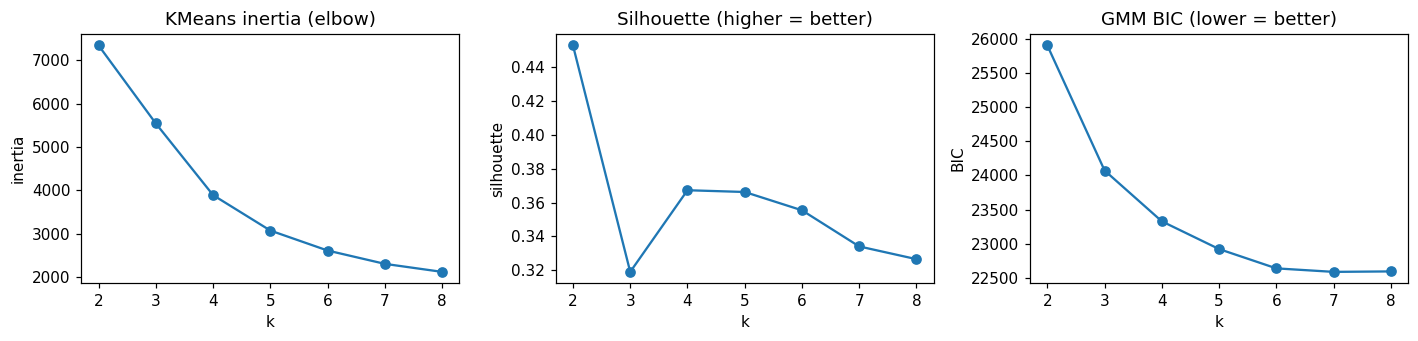

Silhouette: {2: np.float64(0.453), 3: np.float64(0.319), 4: np.float64(0.367), 5: np.float64(0.366), 6: np.float64(0.355), 7: np.float64(0.334), 8: np.float64(0.327)}
BIC      : {2: np.float64(25899.0), 3: np.float64(24072.0), 4: np.float64(23329.0), 5: np.float64(22924.0), 6: np.float64(22642.0), 7: np.float64(22591.0), 8: np.float64(22598.0)}


In [37]:
ks = list(range(2, 9))
inertia, sil, bic = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_, sample_size=2000, random_state=42))
    gm = GaussianMixture(n_components=k, covariance_type="full",
                         n_init=5, random_state=42).fit(Xs)
    bic.append(gm.bic(Xs))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(ks, inertia, "o-"); axes[0].set_title("KMeans inertia (elbow)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(ks, sil, "o-"); axes[1].set_title("Silhouette (higher = better)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
axes[2].plot(ks, bic, "o-"); axes[2].set_title("GMM BIC (lower = better)")
axes[2].set_xlabel("k"); axes[2].set_ylabel("BIC")
plt.tight_layout(); plt.show()

print("Silhouette:", dict(zip(ks, np.round(sil, 3))))
print("BIC      :", dict(zip(ks, np.round(bic, 0))))


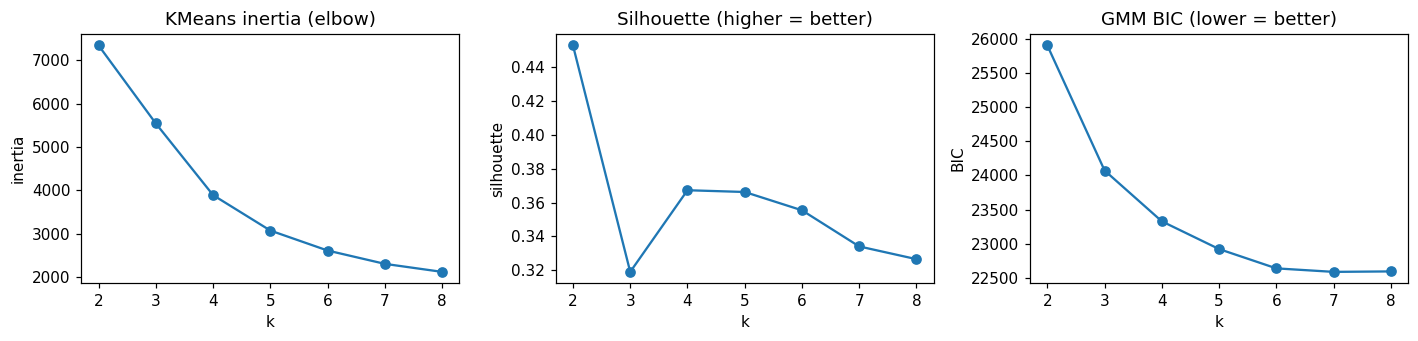

Silhouette: {2: np.float64(0.453), 3: np.float64(0.319), 4: np.float64(0.367), 5: np.float64(0.366), 6: np.float64(0.355), 7: np.float64(0.334), 8: np.float64(0.327)}
BIC      : {2: np.float64(25899.0), 3: np.float64(24072.0), 4: np.float64(23329.0), 5: np.float64(22924.0), 6: np.float64(22642.0), 7: np.float64(22591.0), 8: np.float64(22598.0)}


In [38]:
ks = list(range(2, 9))
inertia, sil, bic = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_, sample_size=2000, random_state=42))
    gm = GaussianMixture(n_components=k, covariance_type="full",
                         n_init=5, random_state=42).fit(Xs)
    bic.append(gm.bic(Xs))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(ks, inertia, "o-"); axes[0].set_title("KMeans inertia (elbow)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(ks, sil, "o-"); axes[1].set_title("Silhouette (higher = better)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
axes[2].plot(ks, bic, "o-"); axes[2].set_title("GMM BIC (lower = better)")
axes[2].set_xlabel("k"); axes[2].set_ylabel("BIC")
plt.tight_layout()
plt.savefig("plots/model_selection_criteria.png") # Save the plot
plt.show()

print("Silhouette:", dict(zip(ks, np.round(sil, 3))))
print("BIC      :", dict(zip(ks, np.round(bic, 0))))

## 4. Fit chosen model

We adopt **k=4** as primary. Rationale:

- BIC monotonically decreases through k=7 (the dataset has fat-tailed,
  non-Gaussian feature distributions, and GMM keeps adding components to
  fit those tails — a well-known BIC failure mode for non-Gaussian data;
  cf. Fraley & Raftery 2002, *J. Am. Stat. Assoc.*).
- Silhouette is highest at k=2 (gross sand/shale) and stable around 0.34-0.37
  for k=4-6.
- k=4 gives a geologically interpretable partition: clean sand, shaly sand,
  shale, and tight/cemented (low-porosity, high-Vp) end-member, which matches
  the expected facies palette of the Lower Cretaceous Mannville Group at
  Blackfoot (Margrave et al. 1998).

Override `K` if you prefer k=2 (binary sand/shale) or k=5 (resolves a coal/
high-GR sub-cluster).


In [39]:
K = 4   # geological default; set to int(np.argmin(bic))+ks[0] for pure-BIC choice

gm = GaussianMixture(n_components=K, covariance_type="full",
                     n_init=10, random_state=42).fit(Xs)
df["CLUSTER_GMM"] = gm.predict(Xs)
df["CLUSTER_PROB_MAX"] = gm.predict_proba(Xs).max(axis=1)

km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(Xs)
df["CLUSTER_KMEANS"] = km.labels_

# Reorder GMM labels by ascending mean Vp so cluster IDs are interpretable
order = (df.groupby("CLUSTER_GMM")["VP_MS"].mean()
           .sort_values().index.tolist())
remap = {old: new for new, old in enumerate(order)}
df["CLUSTER"] = df["CLUSTER_GMM"].map(remap)

print(f"Selected K = {K}")
print("\nCluster centroids in original units:")
print(df.groupby("CLUSTER")[features].mean().round(2))
print("\nCluster sizes:")
print(df.groupby("CLUSTER").size())
print("\nLow-confidence assignments (max prob < 0.7):",
      (df['CLUSTER_PROB_MAX'] < 0.7).sum(), "of", len(df))


Selected K = 4

Cluster centroids in original units:
           VP_MS  DPSS  GR_API
CLUSTER                       
0        3562.20  0.23   99.33
1        3771.70  0.17   37.73
2        4180.18  0.05   89.86
3        4670.91  0.01   58.91

Cluster sizes:
CLUSTER
0     576
1     515
2    2195
3     530
dtype: int64

Low-confidence assignments (max prob < 0.7): 413 of 3816


In [40]:
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

# Define primary-like colors for 4 clusters
# Cluster 0: Red
# Cluster 1: Blue
# Cluster 2: Green
# Cluster 3: Yellow
primary_colors_hex = ["#FF0000", "#0000FF", "#008000", "#FFFF00"] # Red, Blue, Green, Yellow
primary_cmap = ListedColormap(primary_colors_hex)
color_map_plotly = {str(i): primary_colors_hex[i] for i in range(K)}

## 5. Rotatable 3D scatter (Plotly — drag to rotate)

In [41]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"  # change to "browser" or "notebook" if not in Colab

fig3d = px.scatter_3d(
    df, x="VP_MS", y="DPSS", z="GR_API",
    color=df["CLUSTER"].astype(str),
    symbol="WELL",
    hover_data=["WELL", "DEPTH_M", "CLUSTER_PROB_MAX"],
    opacity=0.75,
    title=f"Reservoir-interval clusters (GMM, K={K})",
    labels={"VP_MS": "Vp (m/s)", "DPSS": "DPSS (frac)",
            "GR_API": "GR (API)", "color": "cluster"},
)
fig3d.update_traces(marker=dict(size=3))
fig3d.update_layout(scene=dict(
    xaxis_title="Vp (m/s)", yaxis_title="DPSS (frac)", zaxis_title="GR (API)"
), legend=dict(itemsizing="constant"))
fig3d.show()

In [48]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"  # change to "browser" or "notebook" if not in Colab

fig3d = px.scatter_3d(
    df, x="VP_MS", y="DPSS", z="GR_API",
    color=df["CLUSTER"].astype(str),
    color_discrete_map=color_map_plotly,
    symbol="WELL",
    hover_data=["WELL", "DEPTH_M", "CLUSTER_PROB_MAX"],
    opacity=0.75,
    title=f"Reservoir-interval clusters (GMM, K={K})",
    labels={"VP_MS": "Vp (m/s)", "DPSS": "DPSS (frac)",
            "GR_API": "GR (API)", "color": "cluster"},
)
fig3d.update_traces(marker=dict(size=3))
fig3d.update_layout(scene=dict(
    xaxis_title="Vp (m/s)", yaxis_title="DPSS (frac)", zaxis_title="GR (API)"
), legend=dict(itemsizing="constant"))
fig3d.show()
# Attempt to explicitly import kaleido before writing, in case it helps refresh the environment
try:
    import kaleido
except ImportError:
    pass # Kaleido is not directly used in the Python script, but for Plotly's backend.
fig3d.write_image("plots/3d_scatter_clusters.png") # Save the plotly figure as a PNG

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


## 6. Cross-section view per well

Plot cluster as a coloured strip vs. depth for each well. This is where the
geological story is read — clusters should track stratigraphic packages.


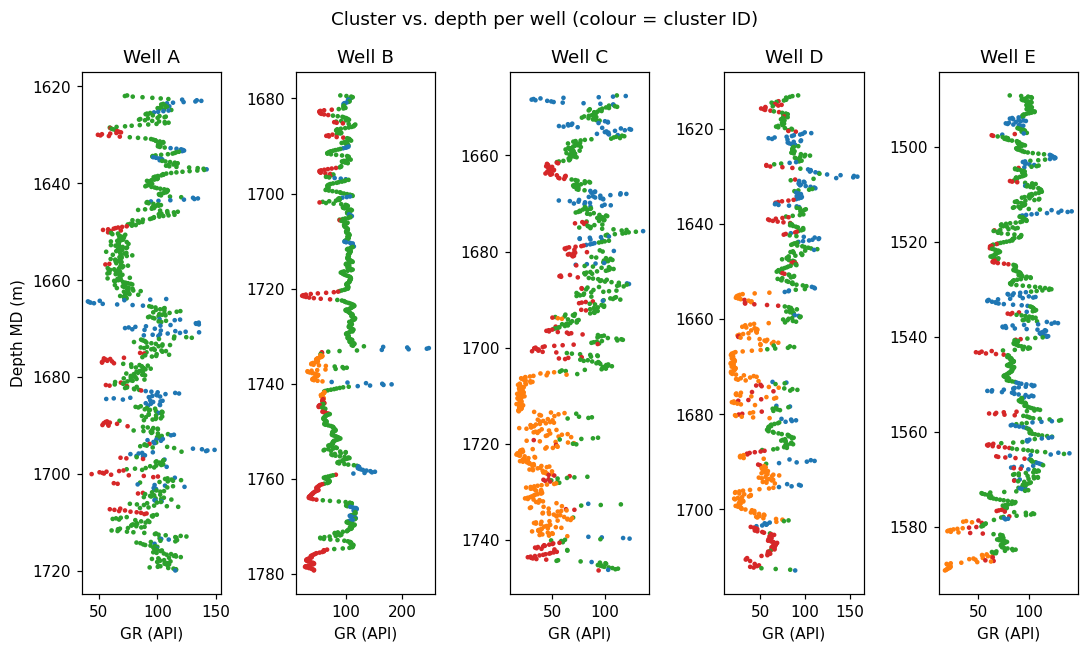

In [49]:
wells = sorted(df["WELL"].unique())
fig, axes = plt.subplots(1, len(wells), figsize=(2.0 * len(wells), 6), sharey=False)
cmap = plt.get_cmap("tab10")
for ax, w in zip(axes, wells):
    sub = df[df["WELL"] == w].sort_values("DEPTH_M")
    ax.scatter(sub["GR_API"], sub["DEPTH_M"],
               c=[cmap(c) for c in sub["CLUSTER"]], s=4)
    ax.invert_yaxis()
    ax.set_title(f"Well {w}")
    ax.set_xlabel("GR (API)")
    if ax is axes[0]:
        ax.set_ylabel("Depth MD (m)")
plt.suptitle("Cluster vs. depth per well (colour = cluster ID)")
plt.tight_layout(); plt.show()


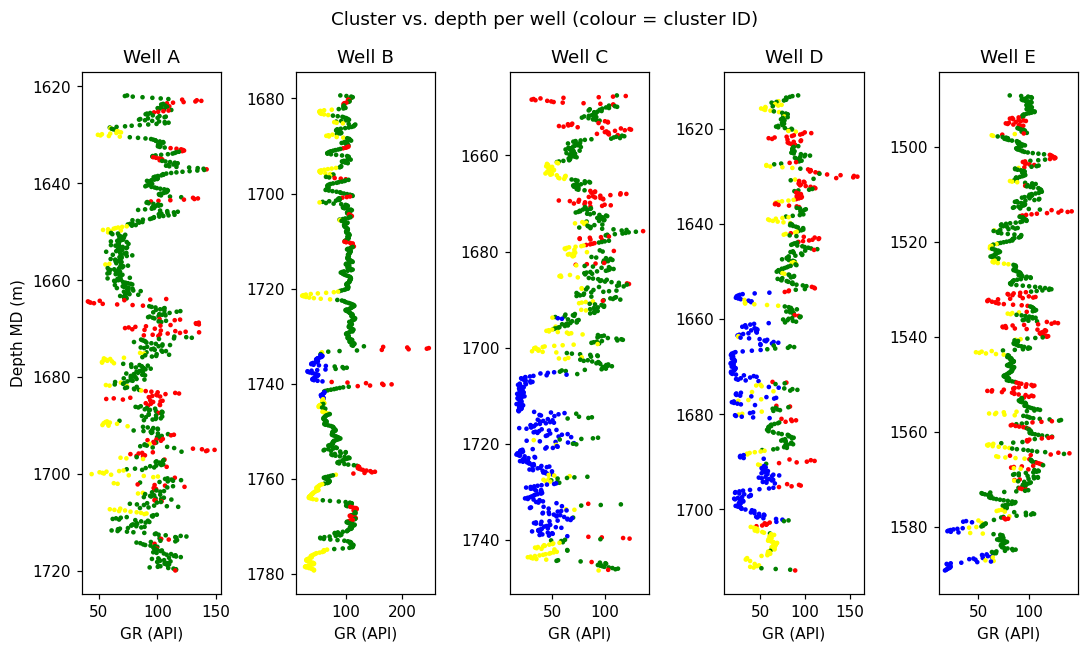

In [46]:
wells = sorted(df["WELL"].unique())
fig, axes = plt.subplots(1, len(wells), figsize=(2.0 * len(wells), 6), sharey=False)
cmap = primary_cmap # Use the custom primary colormap
for ax, w in zip(axes, wells):
    sub = df[df["WELL"] == w].sort_values("DEPTH_M")
    ax.scatter(sub["GR_API"], sub["DEPTH_M"],
               c=sub["CLUSTER"], cmap=cmap, s=4)
    ax.invert_yaxis()
    ax.set_title(f"Well {w}")
    ax.set_xlabel("GR (API)")
    if ax is axes[0]:
        ax.set_ylabel("Depth MD (m)")
plt.suptitle("Cluster vs. depth per well (colour = cluster ID)")
plt.tight_layout()
plt.savefig("plots/well_cross_sections.png") # Save the plot
plt.show()

## 7. Save labelled output

In [ ]:
df.to_csv("blackfoot_clustered.csv", index=False)
print("Saved blackfoot_clustered.csv with shape", df.shape)


## 8. Geological interpretation and visualization recommendations

**Cluster labelling guide (for k=4, ordered by ascending Vp):**

| Cluster | Vp (m/s) | DPSS | GR | Geological interpretation |
|---------|----------|------|----|---------------------------|
| 0 | low (~3000-3500) | high (>0.20) | high (>90) | **Coal / organic-rich shale.** Anomalously low Vp + low density (high apparent DPSS) is the diagnostic signature of coals in the Mannville (Bird et al. 1994). Verify with caliper. |
| 1 | mid-low (~3700-3900) | mid (~0.10-0.20) | high (>80) | **Shale.**  |
| 2 | mid-high (~4000-4400) | low-mid (~0.05-0.15) | low (<70) | **Clean to slightly shaly sand** - the clean sand reservoir target. |
| 3 | high (>4400) | very low (<0.05) | variable | **Tight / cemented sand or carbonate stringer.** Possible calcite-cemented zone (Hutcheon et al. 1989, AAPG). |

**Recommended additional features to add** (in order of expected discriminating power):

1. **Vp/Vs (or Poisson's ratio)** - the single most diagnostic feature for fluid and lithology discrimination (Castagna et al. 1985; Goodway et al. 1997, *TLE*). Well D has DTS, the rest do not. Workaround: predict Vs from Vp using Castagna's mudrock line, but this destroys the very discrimination you want.
2. **Acoustic impedance AI = Vp x rho** (Mavko et al. 2009) - reduces Vp-rho correlation that already hides in your feature set.
3. **Neutron-density separation (NPSS - DPSS)** - first-order gas indicator and shale flag (Asquith & Krygowski 2004, AAPG Methods 16).
4. **Resistivity (ILD)** - separates wet from hydrocarbon-bearing sands; orthogonal to porosity and lithology axes.

**Visualization improvements:**

- **Replace 3D scatter with cross-plot matrix (Vp vs DPSS, Vp vs GR, DPSS vs GR)** for quantitative work. 3D is good for presentations; 2D pair-plots are better for petrophysical reading because human pattern recognition fails above 2D.
- **Colour by depth instead of cluster** in a separate panel to check whether clusters are stratigraphically coherent or scattered (the latter would suggest you're clustering noise).
- **Lasso-select specific clusters in plotly and re-plot in cross-section** - this is the standard interactive interpretation workflow.
- **Cluster transition probability matrix** - count adjacent-depth label transitions; high diagonal = stratigraphically stable clusters, off-diagonal = thin-bed or noise.

**Caveats — be honest about these in any report:**

- DPSS is a **sandstone-matrix porosity** (rho_ma = 2.65 g/cc assumed). In carbonates or anhydrite-cemented zones it goes negative, which here is being clustered as "tight" — not as a separate lithology.
- 3,816 samples / 5 wells is small. Cluster boundaries are sample-driven, not consensus-validated. Bootstrapping the GMM fit (e.g. 100 random subsamples) and reporting label-stability per sample (ARI between runs; Hubert & Arabie 1985) is good practice before publication.
- Clustering only within the TOP-BASE window means we have no "background" to compare against. Consider running the same pipeline on a wider window (e.g. TOP-200 m to BASE+50 m) to verify the reservoir clusters are distinguishable from the encasing shales.
- KMeans assumes spherical clusters; GMM with full covariance is better but assumes Gaussianity per cluster. Petrophysical clouds are typically log-normal in Vp and bimodal in GR. A robust alternative is HDBSCAN (Campello et al. 2013), which makes no parametric assumption — worth a follow-up.


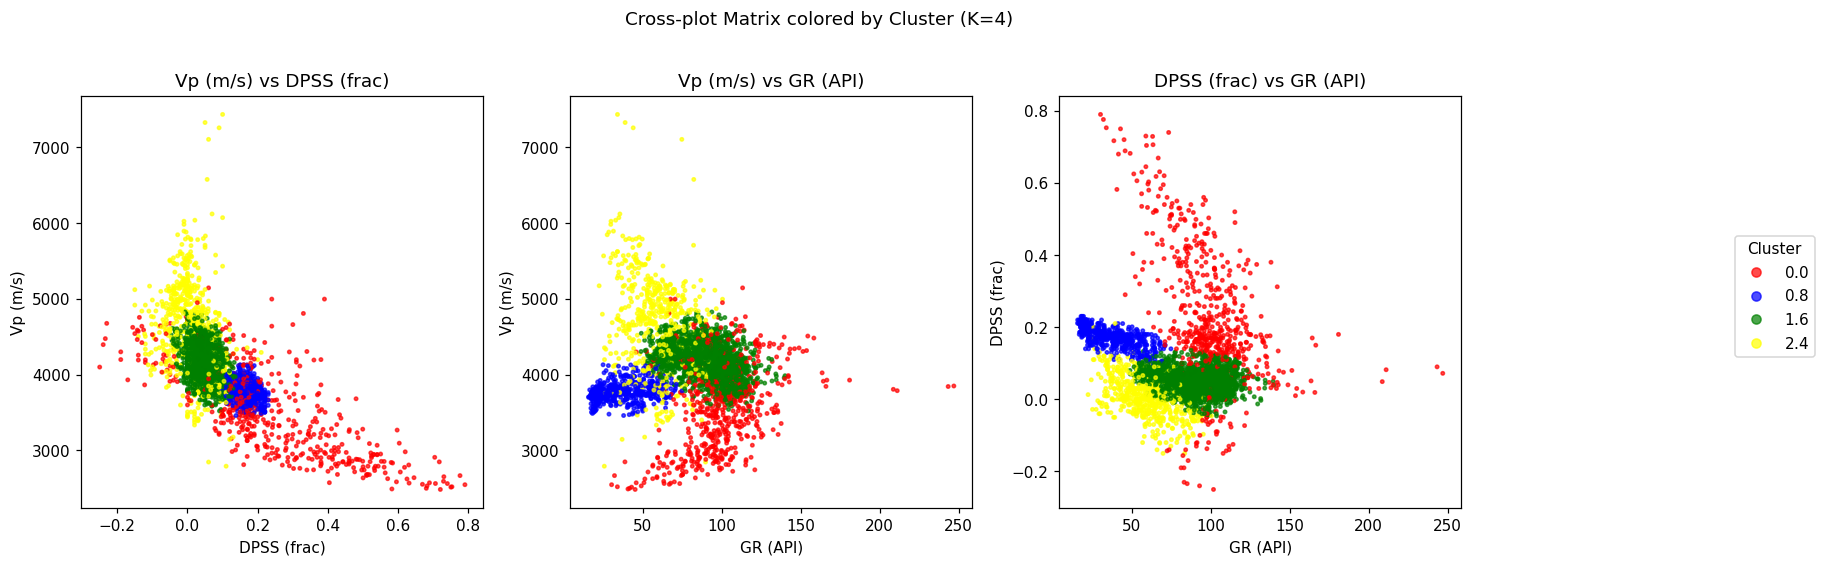

In [47]:
import matplotlib.pyplot as plt

# Define the features for the cross-plot matrix
features_for_cross_plot = [("DPSS", "VP_MS"), ("GR_API", "VP_MS"), ("GR_API", "DPSS")]
feature_labels = {"VP_MS": "Vp (m/s)", "DPSS": "DPSS (frac)", "GR_API": "GR (API)"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cmap = primary_cmap # Use the custom primary colormap

for i, (x_feature, y_feature) in enumerate(features_for_cross_plot):
    ax = axes[i]
    scatter = ax.scatter(df[x_feature], df[y_feature], c=df["CLUSTER"], cmap=cmap, s=5, alpha=0.7)
    ax.set_xlabel(feature_labels[x_feature])
    ax.set_ylabel(feature_labels[y_feature])
    ax.set_title(f"{feature_labels[y_feature]} vs {feature_labels[x_feature]}")

# Add a single legend for the clusters to the figure
handles, labels = scatter.legend_elements(num=K) # K is defined as 4
legend = fig.legend(handles, labels, title="Cluster", bbox_to_anchor=(1.05, 0.5), loc='center left')
# Ensure cluster labels are integers, not floats (e.g., '0' instead of '0.0')
for text in legend.get_texts():
    try:
        text.set_text(str(int(float(text.get_text()))))
    except ValueError:
        pass # Keep original label if conversion fails

plt.suptitle(f"Cross-plot Matrix colored by Cluster (K={K})", y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for legend
plt.savefig("plots/cross_plot_matrix_clusters.png", bbox_inches='tight') # Save the plot
plt.show()